## URBAN DELIVERY DEMAND PREDICTION- Graphsage model

Urban delivery platforms need to understand where demand is likely to be high so they can plan driver availability, restaurant support, and delivery operations more effectively. In this use case, restaurants are represented as nodes in a graph, and nearby restaurants are connected using location-based edges. This allows the model to learn not only from each restaurant’s own order patterns, but also from neighbouring restaurants that may have similar demand behaviour.

# 2. User Story

As an operations or logistics manager for an urban delivery platform, I want to predict restaurant-level delivery demand using order and location data so that I can make better decisions about driver allocation, delivery planning, and operational efficiency.

# 3. Introduction

This notebook demonstrates how GraphSAGE can be used for urban delivery demand prediction. GraphSAGE is a Graph Neural Network method that learns node representations by combining information from each node and its neighbours. In this project, each restaurant is treated as a node, and edges are created based on spatial proximity between restaurants.

The workflow covers data loading, preprocessing, feature engineering, graph construction, model training, and evaluation. The final model predicts demand at restaurant level using engineered features and graph structure.


# 4. Dataset Description

The dataset used in this notebook is `talabat_enhanced_orders.csv`, an external urban delivery order dataset. It includes order-level information such as order time, delivery time, restaurant location, customer location, order status, quantity, traffic level, payment method, and driver vehicle type.

For this GraphSAGE use case, the order-level data is aggregated into restaurant-level data. Each restaurant becomes one node in the graph. The main target variable is total demand, represented using the total quantity of orders for each restaurant.


# 5. Learning Outcomes

By the end of this notebook, the user should be able to:

- Understand how order-level delivery data can be transformed into restaurant-level graph data.
- Create useful time-based and delivery-duration features for demand prediction.
- Construct graph nodes and edges using restaurant location information.
- Convert tabular data into tensors suitable for PyTorch Geometric.
- Train a basic GraphSAGE model for regression.
- Evaluate model performance using MAE, RMSE, R², and actual-versus-predicted visualisations.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [1]:
import pandas as pd
from pathlib import Path

# Load the external dataset from the DEPENDENCIES folder so reviewers can run the notebook.

dataset_path = Path('/Users/blessypaul/Documents/MOP-Code/DEPENDENCIES/talabat_enhanced_orders.csv')

df = pd.read_csv(dataset_path)
df.head()

,Order_ID,User_ID,Restaurant_ID,Driver_ID,Item_Name,Quantity,Total_Price,Order_Time,Delivery_Time,Delivery_Duration_Minutes,...,Driver_Vehicle,Restaurant_Lat,Restaurant_Lon,Customer_Lat,Customer_Lon,Driver_Lat,Driver_Lon,Delivery_Distance_km,Traffic_Level,Driver_Availability
0,1,U3522,358,485,Fried Chicken,3,273.72,2025-06-16 08:32:00,2025-06-16 09:11:00,39,...,Motorbike,31.195082,29.921931,31.191404,29.904982,31.215658,29.910664,1.666106,High,Offline
1,2,U9214,316,65,Sandwich,3,365.82,2025-06-03 21:27:00,2025-06-03 22:00:00,33,...,Motorbike,30.605729,31.503079,30.586047,31.485820,30.580329,31.502380,2.738698,Low,Online
2,3,U7307,357,309,Koshary,3,401.94,2025-06-01 14:48:00,2025-06-01 15:26:00,38,...,Car,27.190180,31.177741,27.164869,31.169218,27.162976,31.189458,2.929079,Medium,Online
3,4,U3612,420,32,Sushi,2,221.18,2025-06-13 02:30:00,2025-06-13 03:22:00,52,...,Car,31.041846,31.381229,31.035773,31.380440,31.054690,31.401187,0.677498,Low,Online
4,5,U3492,73,364,Koshary,5,355.55,2025-06-06 09:48:00,2025-06-06 10:32:00,44,...,Motorbike,31.024141,31.376104,31.026023,31.396881,31.035350,31.389315,1.994769,High,Online


# 6. Data Preprocessing

This section checks the structure of the dataset, identifies missing values and duplicates, converts time columns into datetime format, removes unrealistic delivery durations, and filters the dataset to keep only delivered orders. These steps help ensure the model is trained on clean and meaningful data.

In [4]:
df.head()
df.shape
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 23 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   Order_ID                   100000 non-null  int64  
 1   User_ID                    100000 non-null  object 
 2   Restaurant_ID              100000 non-null  int64  
 3   Driver_ID                  100000 non-null  int64  
 4   Item_Name                  100000 non-null  object 
 5   Quantity                   100000 non-null  int64  
 6   Total_Price                100000 non-null  float64
 7   Order_Time                 100000 non-null  object 
 8   Delivery_Time              100000 non-null  object 
 9   Delivery_Duration_Minutes  100000 non-null  int64  
 10  City                       100000 non-null  object 
 11  Payment_Method             100000 non-null  object 
 12  Order_Status               100000 non-null  object 
 13  Driver_Vehicle             100

In [5]:
#1.check null values
 
df.isnull().sum()

Order_ID                     0
User_ID                      0
Restaurant_ID                0
Driver_ID                    0
Item_Name                    0
Quantity                     0
Total_Price                  0
Order_Time                   0
Delivery_Time                0
Delivery_Duration_Minutes    0
City                         0
Payment_Method               0
Order_Status                 0
Driver_Vehicle               0
Restaurant_Lat               0
Restaurant_Lon               0
Customer_Lat                 0
Customer_Lon                 0
Driver_Lat                   0
Driver_Lon                   0
Delivery_Distance_km         0
Traffic_Level                0
Driver_Availability          0
dtype: int64

In [6]:
#2.check duplicate values
 
df.duplicated().sum()

0

In [7]:
#3.convert date and time columns
 
df['Order_Time'] = pd.to_datetime(df['Order_Time'])
df['Delivery_Time'] = pd.to_datetime(df['Delivery_Time'])
 
df[['Order_Time', 'Delivery_Time']].head()

,Order_Time,Delivery_Time
0,2025-06-16 08:32:00,2025-06-16 09:11:00
1,2025-06-03 21:27:00,2025-06-03 22:00:00
2,2025-06-01 14:48:00,2025-06-01 15:26:00
3,2025-06-13 02:30:00,2025-06-13 03:22:00
4,2025-06-06 09:48:00,2025-06-06 10:32:00


# 7. Feature Engineering

Feature engineering is used to create new variables that better represent delivery demand patterns. Time-based features such as order hour, order day, order month, weekday, and weekend status are extracted from the order timestamp. Delivery duration is also calculated using the difference between delivery time and order time.

The data is then grouped by restaurant so that each restaurant can be represented as one graph node.


In [8]:
#4.Creating time based Features.
df['order_hour'] = df['Order_Time'].dt.hour
df['order_day'] = df['Order_Time'].dt.day
df['order_month'] = df['Order_Time'].dt.month
df['order_weekday'] = df['Order_Time'].dt.weekday
df['is_weekend'] = df['order_weekday'].isin([5, 6]).astype(int)

In [9]:
#5.Creating delivery duration column
df['delivery_duration_mins'] = (df['Delivery_Time'] - df['Order_Time']).dt.total_seconds() / 60
 
df['delivery_duration_mins'].describe()

count    100000.000000
mean         37.520110
std          10.060876
min          15.000000
25%          30.000000
50%          38.000000
75%          45.000000
max          60.000000
Name: delivery_duration_mins, dtype: float64

In [10]:
#6.check categorical values
 
categorical_cols = ['Payment_Method', 'Traffic_Level', 'Order_Status', 'Driver_Vehicle']
for col in categorical_cols:
    if col in df.columns:
        print(col, df[col].value_counts())

Payment_Method Payment_Method
Cash           33528
Wallet         33250
Credit Card    33222
Name: count, dtype: int64
Traffic_Level Traffic_Level
Low       45826
High      29220
Medium    24954
Name: count, dtype: int64
Order_Status Order_Status
Delivered     85197
Cancelled      9812
In Transit     4991
Name: count, dtype: int64
Driver_Vehicle Driver_Vehicle
Bicycle      33393
Car          33362
Motorbike    33245
Name: count, dtype: int64


In [11]:
#7.location information
 
location_cols = ['Restaurant_Lat', 'Restaurant_Lon', 'Customer_Lat', 'Customer_Lon']
df[location_cols].describe()

,Restaurant_Lat,Restaurant_Lon,Customer_Lat,Customer_Lon
count,100000.000000,100000.000000,100000.000000,100000.000000
mean,30.119015,31.063065,30.119060,31.062971
std,1.271638,0.487754,1.271674,0.487811
min,27.160900,29.898701,27.160900,29.898706
25%,30.023110,31.008774,30.023370,31.008460
50%,30.587306,31.209099,30.587054,31.208817
75%,31.026912,31.371676,31.027112,31.371856
max,31.220099,31.521997,31.220096,31.521995


In [12]:
#8.Removing unrealistic values
 
df = df[df['delivery_duration_mins'] >= 0]
 
#9. Filtering only Completed orders
 
df = df[df['Order_Status'] == 'Delivered']

In [13]:
# 9 Group data by Restaurant_ID to convert order-level data → node-level data

restaurant_demand = df.groupby('Restaurant_ID').agg({
    'Quantity': 'sum',                      # total demand per restaurant
    'delivery_duration_mins': 'mean',       # average delivery time
    'order_hour': 'mean'                    # average order time (hour)
}).reset_index()

# View the aggregated data
restaurant_demand.head()

,Restaurant_ID,Quantity,delivery_duration_mins,order_hour
0,1,301,37.755319,10.851064
1,2,247,36.823529,10.870588
2,3,201,36.611111,11.472222
3,4,280,38.471264,11.459770
4,5,238,37.500000,12.200000


In [14]:
# 10 Select features that will be used as input to GraphSAGE

node_features = restaurant_demand[['Quantity', 'delivery_duration_mins', 'order_hour']]

# Check features
node_features.head()

,Quantity,delivery_duration_mins,order_hour
0,301,37.755319,10.851064
1,247,36.823529,10.870588
2,201,36.611111,11.472222
3,280,38.471264,11.459770
4,238,37.500000,12.200000


In [15]:
# 11 Convert Restaurant_ID → numerical indices (required for graph models)

node_ids = restaurant_demand['Restaurant_ID'].unique()

# Create dictionary mapping: Restaurant_ID → index
node_mapping = {id: i for i, id in enumerate(node_ids)}

# Check mapping
list(node_mapping.items())[:5]

[(1, 0), (2, 1), (3, 2), (4, 3), (5, 4)]

# 8. Graph Construction

In this section, restaurants are converted into graph nodes. Each node contains restaurant-level features such as total quantity, average delivery duration, and average order hour. Edges are created between restaurants that are geographically close to each other using latitude and longitude values.

This graph structure allows GraphSAGE to learn from both restaurant-level features and neighbouring restaurant relationships.


In [16]:
# 12 Get average latitude and longitude for each restaurant

restaurant_locations = df.groupby('Restaurant_ID')[['Restaurant_Lat', 'Restaurant_Lon']].mean().reset_index()

# View locations
restaurant_locations.head()

,Restaurant_ID,Restaurant_Lat,Restaurant_Lon
0,1,29.988616,31.072152
1,2,30.126295,31.078475
2,3,30.150074,31.124903
3,4,30.221218,31.039706
4,5,30.291201,31.054879


In [17]:
# 13 Create edges based on distance

from sklearn.metrics.pairwise import euclidean_distances

# Extract coordinates
coords = restaurant_locations[['Restaurant_Lat', 'Restaurant_Lon']].values

# Compute distance matrix between all restaurants
dist_matrix = euclidean_distances(coords)

# Create edges list
edges = []

# Define threshold (distance for connecting nodes)
threshold = 0.01  # you can tune this later

# Connect nodes if distance is small
for i in range(len(coords)):
    for j in range(len(coords)):
        if i != j and dist_matrix[i][j] < threshold:
            edges.append([i, j])

# Check edges
len(edges)

3592

In [18]:
# Convert node features and edges into tensors

import torch

# Convert node features into tensor format
# These are the input features for each restaurant node
x = torch.tensor(node_features.values, dtype=torch.float)

# Convert edges into PyTorch Geometric format
# edge_index should have shape [2, number_of_edges]
edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()

# Check tensor shapes
print("Node feature shape:", x.shape)
print("Edge index shape:", edge_index.shape)

Node feature shape: torch.Size([1000, 3])
Edge index shape: torch.Size([2, 3592])


In [19]:
# Create target variable
# We will predict total demand (Quantity) for each restaurant

y = torch.tensor(restaurant_demand['Quantity'].values, dtype=torch.float)

# Check target shape
print("Target shape:", y.shape)

Target shape: torch.Size([1000])


In [20]:
#Create training and testing indices

from sklearn.model_selection import train_test_split
import numpy as np

# Create indices for all nodes
indices = np.arange(len(restaurant_demand))

# Split node indices into training and testing sets
train_idx, test_idx = train_test_split(indices, test_size=0.2, random_state=42)

# Convert indices into tensors
train_idx = torch.tensor(train_idx, dtype=torch.long)
test_idx = torch.tensor(test_idx, dtype=torch.long)

# Check sizes
print("Training nodes:", len(train_idx))
print("Testing nodes:", len(test_idx))

Training nodes: 800
Testing nodes: 200


In [21]:
# Check PyTorch Geometric first

import torch_geometric
print("PyTorch Geometric is installed")

PyTorch Geometric is installed


In [22]:
# Create graph data object

from torch_geometric.data import Data

# Create graph object
data = Data(x=x, edge_index=edge_index, y=y)

print(data)

Data(x=[1000, 3], edge_index=[2, 3592], y=[1000])


# 9. GraphSAGE Modelling

This section defines and trains a GraphSAGE model using PyTorch Geometric. The model uses two GraphSAGE convolution layers. The first layer learns hidden node representations, and the second layer produces a regression output for demand prediction.

The model is trained using Mean Squared Error loss and the Adam optimiser.


In [23]:
# Define GraphSAGE model

import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv

class GraphSAGEModel(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super(GraphSAGEModel, self).__init__()
        
        # First GraphSAGE layer
        self.conv1 = SAGEConv(in_channels, hidden_channels)
        
        # Second GraphSAGE layer
        self.conv2 = SAGEConv(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        return x

In [24]:
# Initialize model

model = GraphSAGEModel(
    in_channels=x.shape[1],   # 3 features
    hidden_channels=16,
    out_channels=1            # regression output
)

print(model)

GraphSAGEModel(
  (conv1): SAGEConv(3, 16, aggr=mean)
  (conv2): SAGEConv(16, 1, aggr=mean)
)


In [25]:
# Optimizer + Loss

import torch.optim as optim

optimizer = optim.Adam(model.parameters(), lr=0.01)
criterion = nn.MSELoss()

In [26]:
# Train model

for epoch in range(200):
    model.train()
    optimizer.zero_grad()

    out = model(data.x, data.edge_index).squeeze()

    loss = criterion(out[train_idx], data.y[train_idx])

    loss.backward()
    optimizer.step()

    if epoch % 20 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

Epoch 0, Loss: 37051.1680
Epoch 20, Loss: 2497.3931
Epoch 40, Loss: 59.8864
Epoch 60, Loss: 28.5024
Epoch 80, Loss: 17.4195
Epoch 100, Loss: 13.0254
Epoch 120, Loss: 10.9997
Epoch 140, Loss: 9.7214
Epoch 160, Loss: 8.7843
Epoch 180, Loss: 8.0166


# 10. Evaluation

The trained model is evaluated using test nodes that were not used during training. The main evaluation metrics are Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² score. Actual-versus-predicted plots are also used to visually inspect how closely the model predictions match the real demand values.

In [27]:
# Evaluate model

from sklearn.metrics import mean_absolute_error, mean_squared_error

model.eval()

with torch.no_grad():
    predictions = model(data.x, data.edge_index).squeeze()

y_true = data.y[test_idx].cpu().numpy()
y_pred = predictions[test_idx].cpu().numpy()

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 2.2341387
RMSE: 2.884988


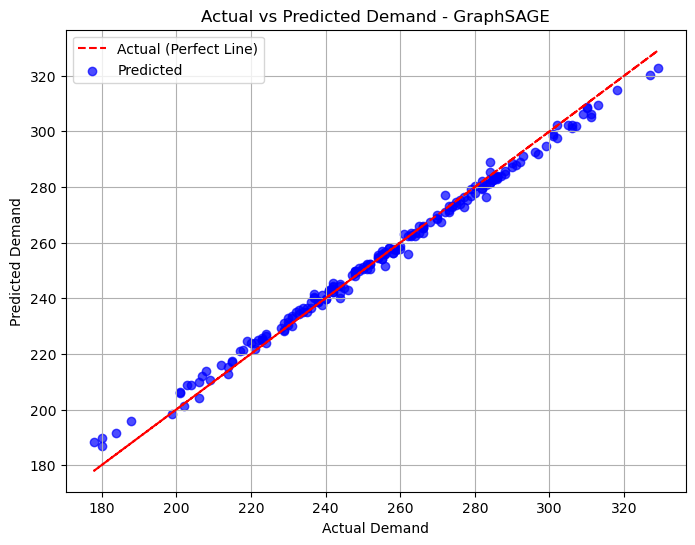

In [28]:
# Plot actual vs predicted 

plt.figure(figsize=(8, 6))

# Actual values (reference line)
plt.plot(y_true, y_true, color='red', linestyle='--', label='Actual (Perfect Line)')

# Predicted values
plt.scatter(y_true, y_pred, color='blue', alpha=0.7, label='Predicted')

plt.xlabel("Actual Demand")
plt.ylabel("Predicted Demand")
plt.title("Actual vs Predicted Demand - GraphSAGE")
plt.legend()
plt.grid(True)
plt.show()

In [29]:
# Create comparison table for actual vs predicted demand

comparison_df = pd.DataFrame({
    'Actual_Demand': y_true,
    'Predicted_Demand': y_pred
})

# Display first 10 rows
comparison_df.head(10)

,Actual_Demand,Predicted_Demand
0,266.0,265.509827
1,257.0,258.066345
2,239.0,241.281631
3,242.0,242.371826
4,231.0,233.568512
5,217.0,220.952911
6,276.0,274.056152
7,248.0,249.440842
8,204.0,208.997330
9,288.0,285.787537


In [30]:
# Calculate R² score

from sklearn.metrics import r2_score

r2 = r2_score(y_true, y_pred)
print("R² Score:", r2)

R² Score: 0.991195315868725


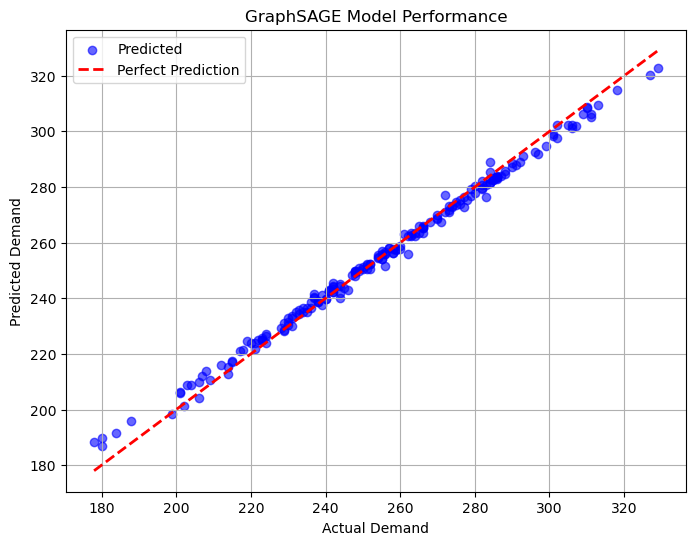

In [31]:
# Better styled plot

plt.figure(figsize=(8, 6))

plt.scatter(y_true, y_pred, color='blue', alpha=0.6, label='Predicted')

plt.plot([min(y_true), max(y_true)],
         [min(y_true), max(y_true)],
         color='red', linestyle='--', linewidth=2, label='Perfect Prediction')

plt.xlabel("Actual Demand")
plt.ylabel("Predicted Demand")
plt.title("GraphSAGE Model Performance")
plt.legend()
plt.grid(True)
plt.show()

In [32]:
# Save trained GraphSAGE model

torch.save(model.state_dict(), "graphsage_model.pth")
print("Model saved successfully as graphsage_model.pth")

Model saved successfully as graphsage_model.pth


In [33]:
# Save comparison results to CSV

comparison_df.to_csv("graphsage_predictions.csv", index=False)
print("Predictions saved successfully as graphsage_predictions.csv")

Predictions saved successfully as graphsage_predictions.csv


In [40]:
# Print final model summary

print("GraphSAGE Model Evaluation Summary")
print("----------------------------------")
print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

GraphSAGE Model Evaluation Summary
----------------------------------
MAE : 2.2341387
RMSE: 2.884988
R²  : 0.991195315868725


# 11. Conclusion

This notebook shows how GraphSAGE can be applied to restaurant-level demand prediction in an urban delivery setting. The graph approach is useful because it includes both individual restaurant features and spatial relationships between nearby restaurants.

The current model provides a foundation for further improvement. Future work could include feature scaling, tuning hidden layer size and learning rate, testing different distance thresholds for edge construction, adding more demand-related features, and comparing GraphSAGE with other models such as LSTM, GAT, and T-GCN.